Load data

In [39]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/export.txt')
print(df.shape)
print(df.columns.tolist())


(1360298, 12)
['Age recode with <1 year olds and 90+', 'Sex', 'Year of diagnosis', 'Primary Site - labeled', 'Histologic Type ICD-O-3', 'Grade Clinical (2018+)', 'Summary stage 2000 (1998-2017)', 'Vital status recode (study cutoff used)', 'Survival months', 'SEER cause-specific death classification', 'Radiation recode', 'Race and origin recode (NHW, NHB, NHAIAN, NHAPI, Hispanic)']


Rename columns


In [40]:
df.columns = [
    'age_group', 'sex', 'year_diagnosis', 'primary_site',
    'histologic_type', 'grade', 'summary_stage', 'vital_status',
    'survival_months', 'cause_specific_death', 'radiation', 'race'
]
print(df.columns.tolist())

['age_group', 'sex', 'year_diagnosis', 'primary_site', 'histologic_type', 'grade', 'summary_stage', 'vital_status', 'survival_months', 'cause_specific_death', 'radiation', 'race']


 Replace Blank(s) with NaN

In [41]:
df.replace('Blank(s)', np.nan, inplace=True)
print(df.isnull().sum())


age_group                     0
sex                           0
year_diagnosis                0
primary_site                  0
histologic_type               0
grade                   1015189
summary_stage            345123
vital_status                  0
survival_months               0
cause_specific_death          0
radiation                     0
race                          0
dtype: int64


Fix survival months

In [42]:
df['survival_months'] = pd.to_numeric(df['survival_months'], errors='coerce')
print(df['survival_months'].dtype)
print(df['survival_months'].head(10))

float64
0     14.0
1     12.0
2     59.0
3     81.0
4      7.0
5    260.0
6     84.0
7     50.0
8    130.0
9     28.0
Name: survival_months, dtype: float64


 Create vital status binary

In [43]:
df['vital_status_binary'] = df['vital_status'].map({'Alive': 0, 'Dead': 1})
print(df['vital_status_binary'].value_counts())
print(df['vital_status_binary'].isnull().sum())

vital_status_binary
0    917617
1    442681
Name: count, dtype: int64
0


Clean age group

In [44]:
df['age_group'] = df['age_group'].str.replace(' years', '').str.strip()
print(df['age_group'].unique())


['75-79' '70-74' '60-64' '40-44' '50-54' '35-39' '80-84' '55-59' '85-89'
 '30-34' '65-69' '90+' '45-49' '25-29' '20-24' '15-19' '01-04' '10-14'
 '05-09' '00']


Drop null survival months and copy

In [45]:
df_clean = df.dropna(subset=['survival_months']).copy()
print(df_clean.shape)

(1354259, 13)


Fix missing grade and summary stage

In [46]:
df_clean['grade_known'] = df_clean['grade'].notna().astype(int)
df_clean['summary_stage'] = df_clean['summary_stage'].fillna('Unknown')
print(df_clean['grade_known'].value_counts())
print(df_clean['summary_stage'].value_counts())

grade_known
0    1010561
1     343698
Name: count, dtype: int64
summary_stage
Localized           633668
Unknown             343712
Regional            300657
Distant              54901
Unknown/unstaged     21321
Name: count, dtype: int64


Clean grade

In [47]:
grade_map = {
    '1': 'Well differentiated',
    '2': 'Moderately differentiated',
    '3': 'Poorly differentiated',
    '9': 'Unknown',
    'H': 'High grade',
    'B': 'Borderline',
    'M': 'Moderate',
    'C': 'Unknown',
    'A': 'Unknown'
}
df_clean['grade_clean'] = df_clean['grade'].map(grade_map).fillna('Unknown')
print(df_clean['grade_clean'].value_counts())

grade_clean
Unknown                      1063774
Moderately differentiated     131489
Well differentiated            75539
Poorly differentiated          68252
Borderline                      6434
High grade                      5078
Moderate                        3693
Name: count, dtype: int64


Fix data types

In [48]:
df_clean['year_diagnosis'] = df_clean['year_diagnosis'].astype(int)
df_clean['histologic_type'] = df_clean['histologic_type'].astype(int)
df_clean['vital_status_binary'] = df_clean['vital_status_binary'].astype(int)
print(df_clean.dtypes)

age_group                object
sex                      object
year_diagnosis            int64
primary_site             object
histologic_type           int64
grade                    object
summary_stage            object
vital_status             object
survival_months         float64
cause_specific_death     object
radiation                object
race                     object
vital_status_binary       int64
grade_known               int64
grade_clean              object
dtype: object


Save cleaned dataset

In [49]:
df_clean.to_csv('breast_cancer_cleaned.csv', index=False)
print("Saved!")
print(df_clean.shape)

Saved!
(1354259, 15)


#Exploratory Data Analysis

Load cleaned dataset and basic check

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('breast_cancer_cleaned.csv')
print(df.shape)
print(df.head())

(1354259, 15)
  age_group     sex  year_diagnosis                        primary_site  \
0     75-79  Female            2003       C50.6-Axillary tail of breast   
1     70-74  Female            2010                   C50.9-Breast, NOS   
2     70-74  Female            2018  C50.8-Overlapping lesion of breast   
3     60-64  Female            2005     C50.1-Central portion of breast   
4     70-74  Female            2005                   C50.9-Breast, NOS   

   histologic_type grade summary_stage vital_status  survival_months  \
0             8520   NaN      Regional         Dead             14.0   
1             8500   NaN     Localized         Dead             12.0   
2             8500     9       Unknown        Alive             59.0   
3             8520   NaN      Regional         Dead             81.0   
4             8500   NaN      Regional         Dead              7.0   

                    cause_specific_death       radiation                race  \
0  Dead (attributable 

Distribution of vital status (how many alive vs dead)

/tmp/ipykernel_19862/4249688726.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='vital_status', palette=['#2ecc71','#e74c3c'])


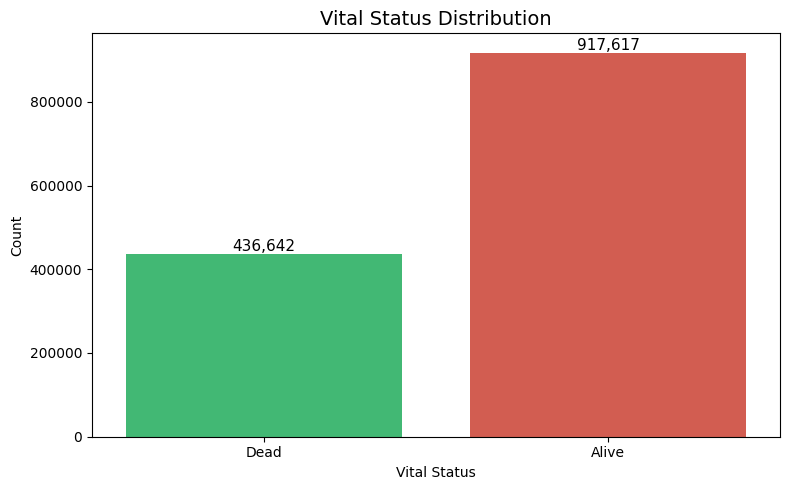

vital_status
Alive    917617
Dead     436642
Name: count, dtype: int64

Mortality rate: 32.2%


In [51]:
plt.figure(figsize=(8,5))
ax = sns.countplot(data=df, x='vital_status', palette=['#2ecc71','#e74c3c'])
plt.title('Vital Status Distribution', fontsize=14)
plt.xlabel('Vital Status')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('vital_status_distribution.png', dpi=150)
plt.show()

print(df['vital_status'].value_counts())
print(f"\nMortality rate: {df['vital_status_binary'].mean()*100:.1f}%")

Age group distribution

/tmp/ipykernel_19862/972724924.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='age_group', order=age_order, palette='Blues_d')


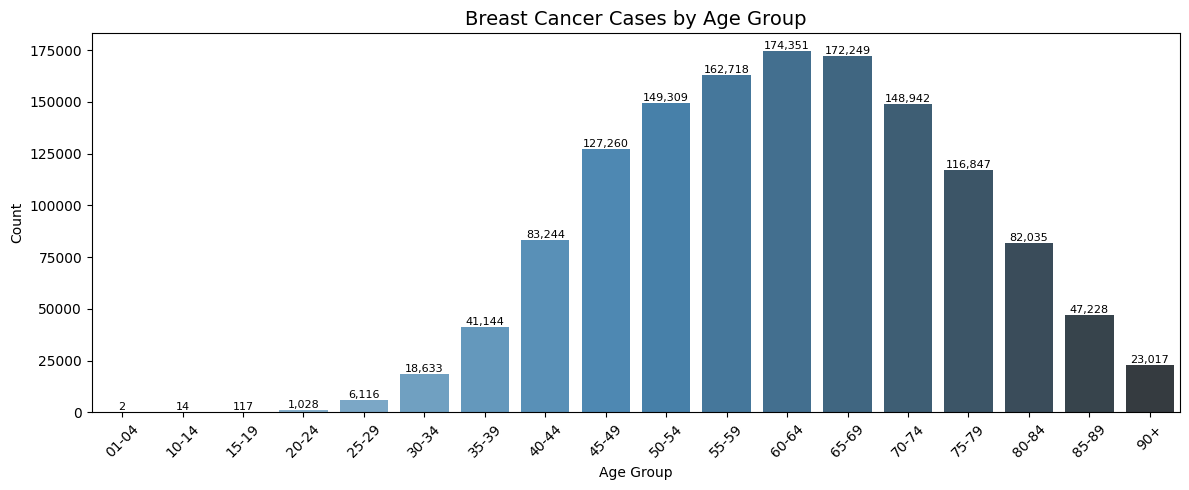

In [52]:
age_order = ['01-04','10-14','15-19','20-24','25-29','30-34',
             '35-39','40-44','45-49','50-54','55-59','60-64',
             '65-69','70-74','75-79','80-84','85-89','90+']

plt.figure(figsize=(12,5))
ax = sns.countplot(data=df, x='age_group', order=age_order, palette='Blues_d')
plt.title('Breast Cancer Cases by Age Group', fontsize=14)
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=45)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('age_distribution.png', dpi=150)
plt.show()

Survival months distribution

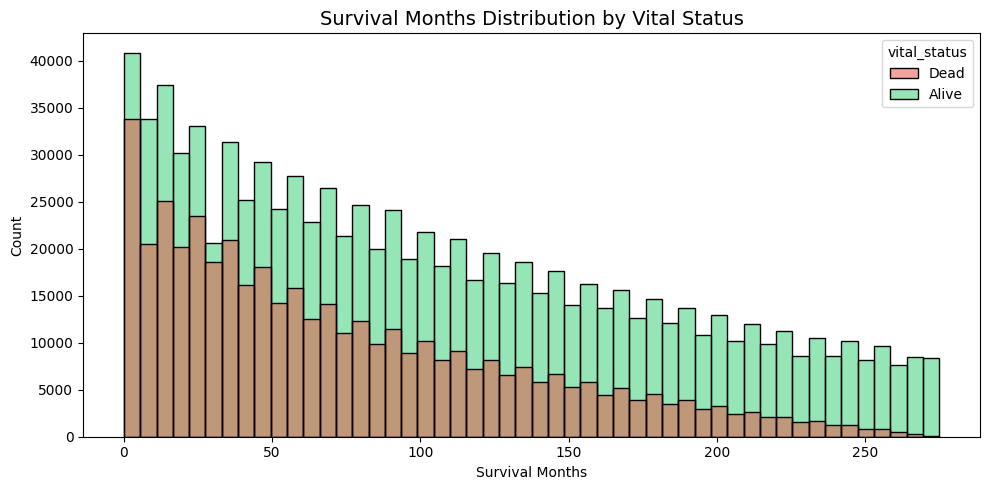

Average survival months (Dead): 73.4
Average survival months (Alive): 103.6


In [53]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='survival_months', bins=50,
             hue='vital_status', palette=['#e74c3c','#2ecc71'])
plt.title('Survival Months Distribution by Vital Status', fontsize=14)
plt.xlabel('Survival Months')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('survival_distribution.png', dpi=150)
plt.show()

print(f"Average survival months (Dead): {df[df['vital_status']=='Dead']['survival_months'].mean():.1f}")
print(f"Average survival months (Alive): {df[df['vital_status']=='Alive']['survival_months'].mean():.1f}")

Mortality rate by cancer stage

/tmp/ipykernel_19862/2268368714.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=stage_mortality, x='summary_stage',


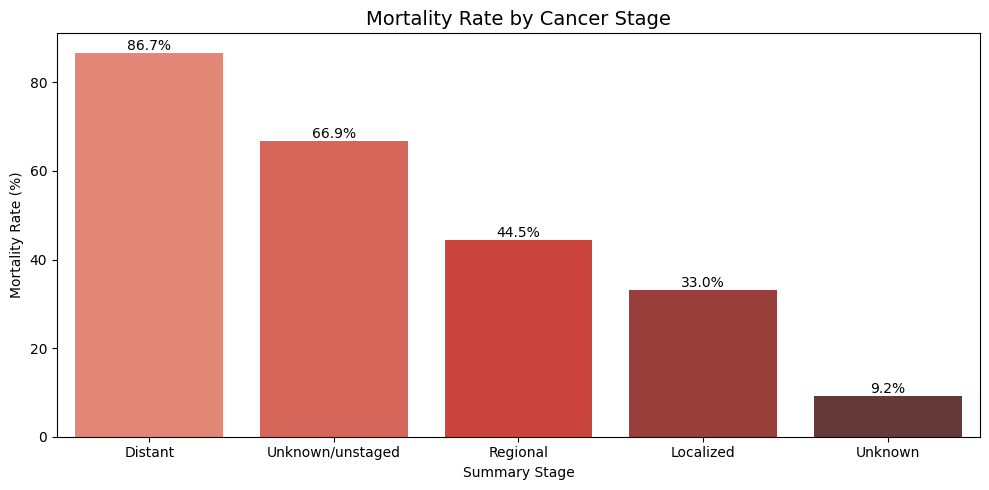

      summary_stage  mortality_rate   count
0           Distant       86.727018   54901
4  Unknown/unstaged       66.854275   21321
2          Regional       44.487905  300657
1         Localized       33.029599  633668
3           Unknown        9.228657  343712


In [54]:
stage_mortality = df.groupby('summary_stage')['vital_status_binary'].agg(['mean','count']).reset_index()
stage_mortality.columns = ['summary_stage', 'mortality_rate', 'count']
stage_mortality['mortality_rate'] = stage_mortality['mortality_rate'] * 100
stage_mortality = stage_mortality.sort_values('mortality_rate', ascending=False)

plt.figure(figsize=(10,5))
ax = sns.barplot(data=stage_mortality, x='summary_stage',
                 y='mortality_rate', palette='Reds_d')
plt.title('Mortality Rate by Cancer Stage', fontsize=14)
plt.xlabel('Summary Stage')
plt.ylabel('Mortality Rate (%)')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('stage_mortality.png', dpi=150)
plt.show()

print(stage_mortality)

Mortality rate by race

/tmp/ipykernel_19862/3547789664.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=race_mortality, x='race',


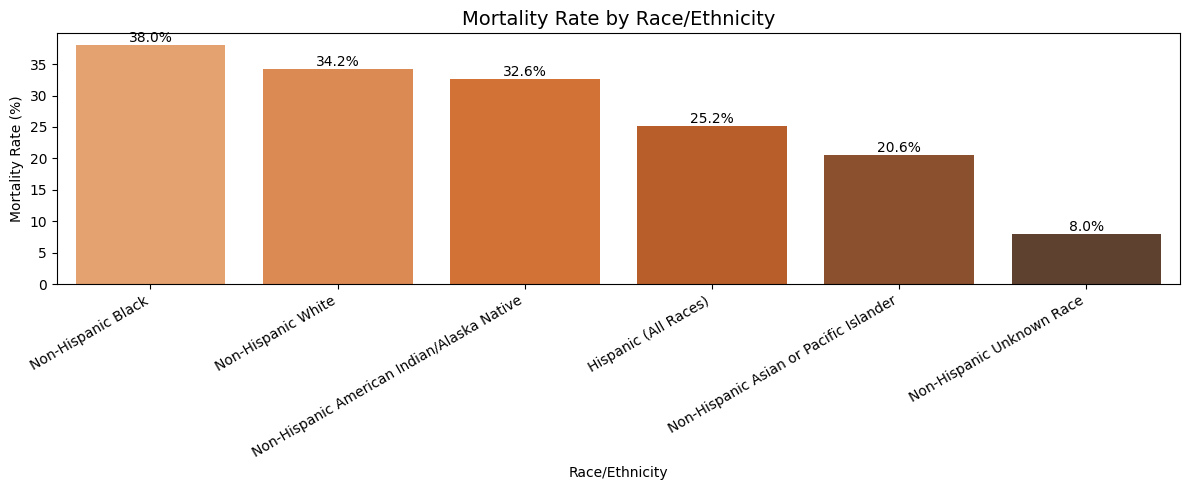

                                         race  mortality_rate   count
3                          Non-Hispanic Black       37.995670  136734
5                          Non-Hispanic White       34.164418  933679
1  Non-Hispanic American Indian/Alaska Native       32.636037    7792
0                        Hispanic (All Races)       25.205154  154274
2      Non-Hispanic Asian or Pacific Islander       20.568676  115637
4                   Non-Hispanic Unknown Race        7.976559    6143


In [55]:
race_mortality = df.groupby('race')['vital_status_binary'].agg(['mean','count']).reset_index()
race_mortality.columns = ['race', 'mortality_rate', 'count']
race_mortality['mortality_rate'] = race_mortality['mortality_rate'] * 100
race_mortality = race_mortality[race_mortality['count'] > 100]
race_mortality = race_mortality.sort_values('mortality_rate', ascending=False)

plt.figure(figsize=(12,5))
ax = sns.barplot(data=race_mortality, x='race',
                 y='mortality_rate', palette='Oranges_d')
plt.title('Mortality Rate by Race/Ethnicity', fontsize=14)
plt.xlabel('Race/Ethnicity')
plt.ylabel('Mortality Rate (%)')
plt.xticks(rotation=30, ha='right')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('race_mortality.png', dpi=150)
plt.show()

print(race_mortality)

Mortality rate by radiation treatment

/tmp/ipykernel_19862/315351084.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=radiation_mortality, x='radiation',


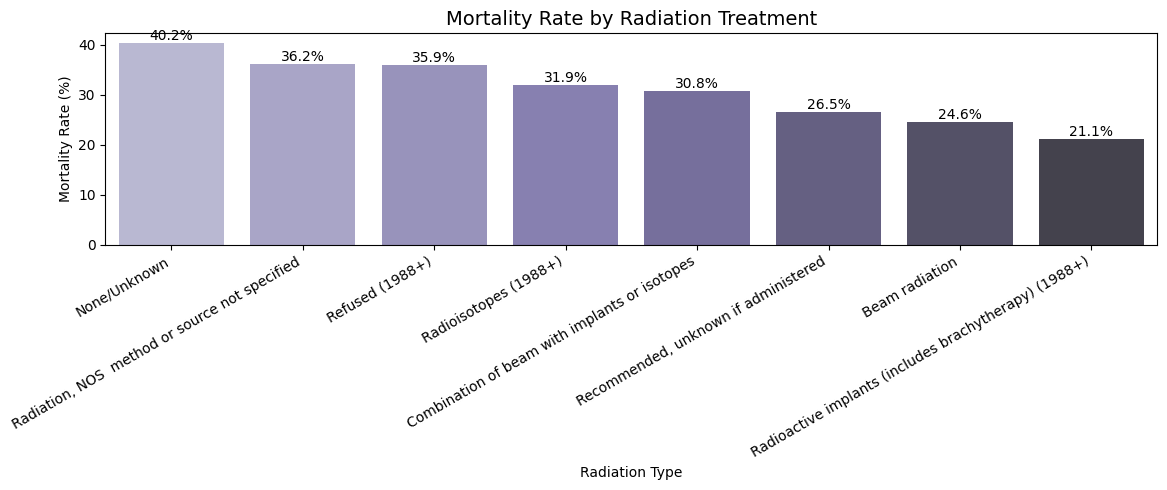

                                           radiation  mortality_rate   count
2                                       None/Unknown       40.242015  633348
3     Radiation, NOS  method or source not specified       36.150614    6188
7                                    Refused (1988+)       35.886465   33188
5                              Radioisotopes (1988+)       31.904762     420
1      Combination of beam with implants or isotopes       30.816714    2106
6               Recommended, unknown if administered       26.481157   32559
0                                     Beam radiation       24.582304  626532
4  Radioactive implants (includes brachytherapy) ...       21.096496   19918


In [56]:
radiation_mortality = df.groupby('radiation')['vital_status_binary'].agg(['mean','count']).reset_index()
radiation_mortality.columns = ['radiation', 'mortality_rate', 'count']
radiation_mortality['mortality_rate'] = radiation_mortality['mortality_rate'] * 100
radiation_mortality = radiation_mortality[radiation_mortality['count'] > 100]
radiation_mortality = radiation_mortality.sort_values('mortality_rate', ascending=False)

plt.figure(figsize=(12,5))
ax = sns.barplot(data=radiation_mortality, x='radiation',
                 y='mortality_rate', palette='Purples_d')
plt.title('Mortality Rate by Radiation Treatment', fontsize=14)
plt.xlabel('Radiation Type')
plt.ylabel('Mortality Rate (%)')
plt.xticks(rotation=30, ha='right')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('radiation_mortality.png', dpi=150)
plt.show()

print(radiation_mortality)

Diagnoses trend over years

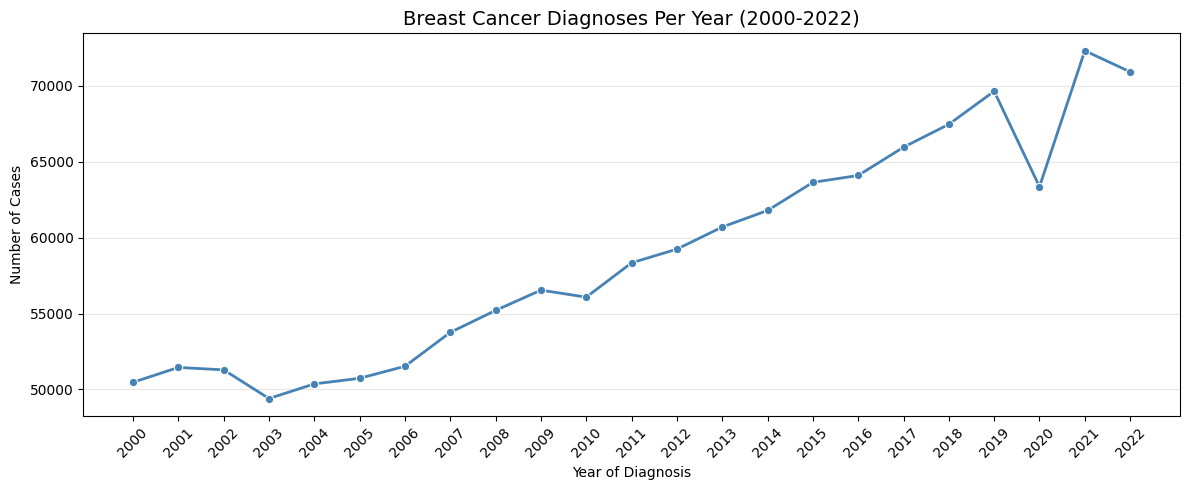

    year_diagnosis  cases
0             2000  50469
1             2001  51447
2             2002  51290
3             2003  49401
4             2004  50363
5             2005  50733
6             2006  51524
7             2007  53756
8             2008  55204
9             2009  56540
10            2010  56078
11            2011  58339
12            2012  59240
13            2013  60698
14            2014  61787
15            2015  63640
16            2016  64096
17            2017  65956
18            2018  67466
19            2019  69644
20            2020  63354
21            2021  72313
22            2022  70921


In [57]:
yearly = df.groupby('year_diagnosis').size().reset_index(name='cases')

plt.figure(figsize=(12,5))
sns.lineplot(data=yearly, x='year_diagnosis', y='cases',
             marker='o', color='steelblue', linewidth=2)
plt.title('Breast Cancer Diagnoses Per Year (2000-2022)', fontsize=14)
plt.xlabel('Year of Diagnosis')
plt.ylabel('Number of Cases')
plt.xticks(yearly['year_diagnosis'], rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('yearly_trend.png', dpi=150)
plt.show()

print(yearly)

Correlation heatmap (numeric columns)

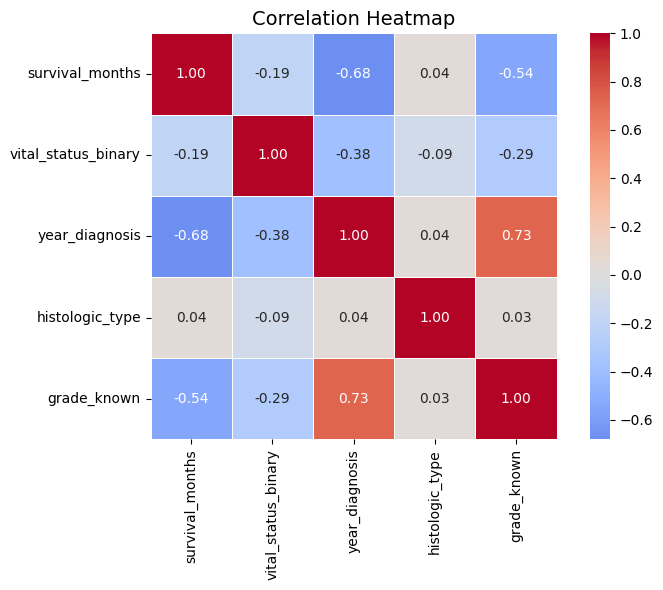

In [58]:
numeric_cols = ['survival_months', 'vital_status_binary',
                'year_diagnosis', 'histologic_type', 'grade_known']

plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(),
            annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()


 Summary statistics export

In [59]:
summary = df.describe(include='all').T
summary.to_csv('eda_summary_statistics.csv')

print("=== EDA COMPLETE ===")
print(f"Total patients: {len(df):,}")
print(f"Mortality rate: {df['vital_status_binary'].mean()*100:.1f}%")
print(f"Average survival (all): {df['survival_months'].mean():.1f} months")
print(f"Most common age group: {df['age_group'].mode()[0]}")
print(f"Most common stage: {df['summary_stage'].mode()[0]}")
print(f"Most common race: {df['race'].mode()[0]}")
print(f"Date range: {df['year_diagnosis'].min()} - {df['year_diagnosis'].max()}")

=== EDA COMPLETE ===
Total patients: 1,354,259
Mortality rate: 32.2%
Average survival (all): 93.9 months
Most common age group: 60-64
Most common stage: Localized
Most common race: Non-Hispanic White
Date range: 2000 - 2022


In [60]:
import os
if os.path.exists('breast_cancer_cleaned.csv'):
    print("File exists!")
    print(f"Size: {os.path.getsize('breast_cancer_cleaned.csv') / 1024 / 1024:.1f} MB")
else:
    print("File not found - need to save again")

File exists!
Size: 206.9 MB


In [61]:
from google.colab import files
files.download('breast_cancer_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [62]:
import pandas as pd
import numpy as np

df = pd.read_csv('breast_cancer_cleaned.csv')
print(df.shape)
print(df.columns.tolist())

(1354259, 15)
['age_group', 'sex', 'year_diagnosis', 'primary_site', 'histologic_type', 'grade', 'summary_stage', 'vital_status', 'survival_months', 'cause_specific_death', 'radiation', 'race', 'vital_status_binary', 'grade_known', 'grade_clean']


#Survival Analysis

Install and import survival analysis libraries

In [63]:
!pip install lifelines --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

df = pd.read_csv('breast_cancer_cleaned.csv')
print(df.shape)
print("Libraries loaded successfully!")

(1354259, 15)
Libraries loaded successfully!


Kaplan-Meier survival curve by cancer stage

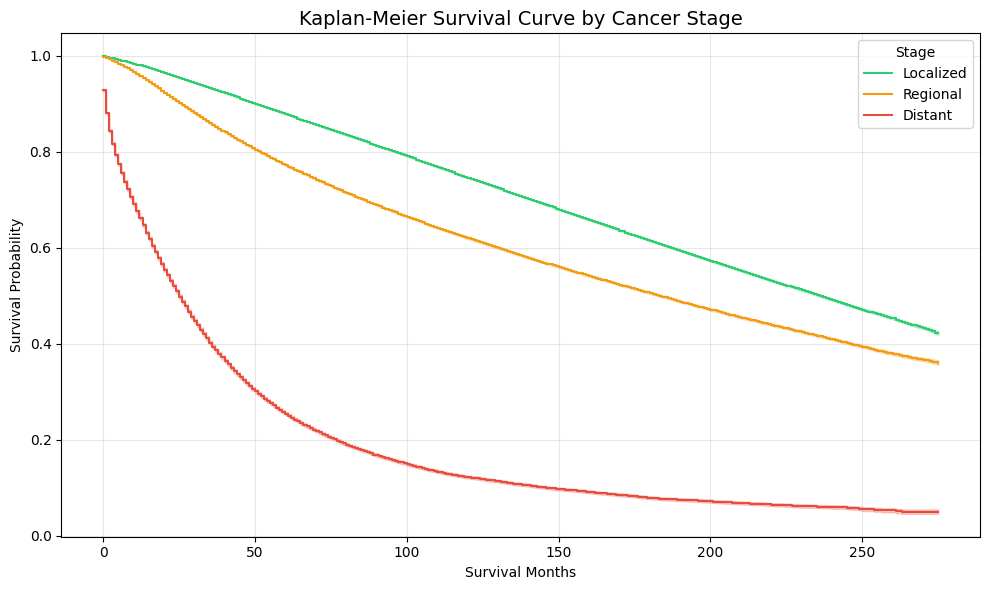

In [64]:
kmf = KaplanMeierFitter()

stages = ['Localized', 'Regional', 'Distant']
colors = ['#2ecc71', '#f39c12', '#e74c3c']

plt.figure(figsize=(10,6))

for stage, color in zip(stages, colors):
    mask = df['summary_stage'] == stage
    kmf.fit(
        df[mask]['survival_months'],
        event_observed=df[mask]['vital_status_binary'],
        label=stage
    )
    kmf.plot_survival_function(ci_show=True, color=color)

plt.title('Kaplan-Meier Survival Curve by Cancer Stage', fontsize=14)
plt.xlabel('Survival Months')
plt.ylabel('Survival Probability')
plt.legend(title='Stage')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('km_curve_stage.png', dpi=150)
plt.show()

Log-rank test (statistical significance)

In [65]:
localized = df[df['summary_stage'] == 'Localized']
regional = df[df['summary_stage'] == 'Regional']
distant = df[df['summary_stage'] == 'Distant']

results = logrank_test(
    localized['survival_months'], distant['survival_months'],
    event_observed_A=localized['vital_status_binary'],
    event_observed_B=distant['vital_status_binary']
)

print(f"Log-rank test: Localized vs Distant")
print(f"Test statistic: {results.test_statistic:.2f}")
print(f"P-value: {results.p_value:.10f}")
print(f"Statistically significant: {results.p_value < 0.05}")

Log-rank test: Localized vs Distant
Test statistic: 236067.99
P-value: 0.0000000000
Statistically significant: True


Kaplan-Meier by race

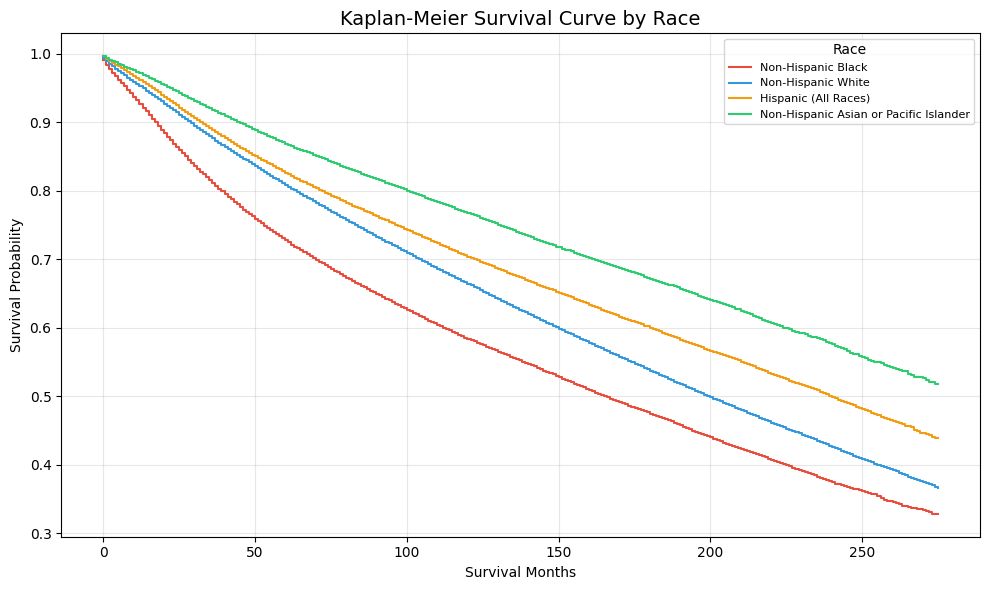

In [66]:
kmf = KaplanMeierFitter()

races = ['Non-Hispanic Black', 'Non-Hispanic White',
         'Hispanic (All Races)', 'Non-Hispanic Asian or Pacific Islander']
colors = ['#e74c3c', '#3498db', '#f39c12', '#2ecc71']

plt.figure(figsize=(10,6))

for race, color in zip(races, colors):
    mask = df['race'] == race
    kmf.fit(
        df[mask]['survival_months'],
        event_observed=df[mask]['vital_status_binary'],
        label=race
    )
    kmf.plot_survival_function(ci_show=False, color=color)

plt.title('Kaplan-Meier Survival Curve by Race', fontsize=14)
plt.xlabel('Survival Months')
plt.ylabel('Survival Probability')
plt.legend(title='Race', fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('km_curve_race.png', dpi=150)
plt.show()

Cox Proportional Hazards model

/usr/local/lib/python3.12/dist-packages/lifelines/utils/__init__.py:1100: ConvergenceWarning: Column(s) ['age_group_01-04', 'age_group_05-09', 'age_group_10-14', 'age_group_15-19'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.

  warnings.warn(dedent(warning_text), ConvergenceWarning)
/usr/local/lib/python3.12/dist-packages/lifelines/utils/__init__.py:1120: ConvergenceWarning: Column age_group_01-04 have very low variance when conditioned on death event present or not. This may harm convergence. This could be a form of 'complete separation'. For example, try the following code:

>>> events = df['vital_status_binary'].astype(bool)
>>> print(df.loc[events, 'age_group_01-04'].var())
>>> print(df.loc[~events, 'age_group_01-04'].var())

A very low variance means that the column age_group_01-04 completely determines whether a subject dies or not. Se

<lifelines.CoxPHFitter: fitted with 1.35426e+06 total observations, 917617 right-censored observations>
             duration col = 'survival_months'
                event col = 'vital_status_binary'
      baseline estimation = breslow
   number of observations = 1.35426e+06
number of events observed = 436642
   partial log-likelihood = -5660310.02
         time fit was run = 2026-05-30 00:44:22 UTC

---
                                                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                        
summary_stage_Localized                         -2.21      0.11      0.01           -2.22           -2.20                0.11                0.11
summary_stage_Regional                          -1.64      0.19      0.01           -1.65           -1.62                0.19                0.20
summary_stage_Unknown                           -1.89      0.15      0.01           -1.91           -1.88                0.15                0.15
summary_stage_Unknown/unstaged                  -1.10      0.33      0.01           -1.12           -1.08                0.33                0.34
race_Non-Hispanic American Indian/Alaska Native  0.23      1.25      0.02            0.19            0.27                1.21                1.31
race_Non-Hispanic Asian or Pacific Islander     -0.26      0.77      0.01           -0.28           -0.25                0.76                0.78
race_Non-Hispanic Black                          0.35      1.42      0.01            0.34            0.36                1.40                1.44
race_Non-Hispanic Unknown Race                  -0.98      0.38      0.05           -1.07           -0.89                0.34                0.41
race_Non-Hispanic White                         -0.05      0.95      0.01           -0.06           -0.04                0.94                0.96
age_group_01-04                                  0.83      2.30   1759.09        -3446.92         3448.59                0.00                 inf
age_group_05-09                                  0.92      2.52   1755.13        -3439.06         3440.91                0.00                 inf
age_group_10-14                                  7.52   1841.99   1754.51        -3431.26         3446.30                0.00                 inf
age_group_15-19                                  8.54   5117.87   1754.51        -3430.24         3447.32                0.00                 inf
age_group_20-24                                  8.81   6701.79   1754.51        -3429.97         3447.59                0.00                 inf
age_group_25-29                                  8.85   6942.45   1754.51        -3429.93         3447.62                0.00                 inf
age_group_30-34                                  8.75   6285.40   1754.51        -3430.03         3447.52                0.00                 inf
age_group_35-39                                  8.65   5697.23   1754.51        -3430.13         3447.43                0.00                 inf
age_group_40-44                                  8.49   4870.68   1754.51        -3430.29         3447.27                0.00                 inf
age_group_45-49                                  8.47   4779.59   1754.51        -3430.31         3447.25                0.00                 inf
age_group_50-54                                  8.66   5769.55   1754.51        -3430.12         3447.44                0.00                 inf
age_group_55-59                                  8.87   7118.15   1754.51        -3429.91         3447.65                0.00                 inf
age_group_60-64                                  9.07   8671.45   1754.51        -3429.71         3447.85                0.00                 inf
age_group_65-69                                  9.36  11623.70   1754.51        -3429.4

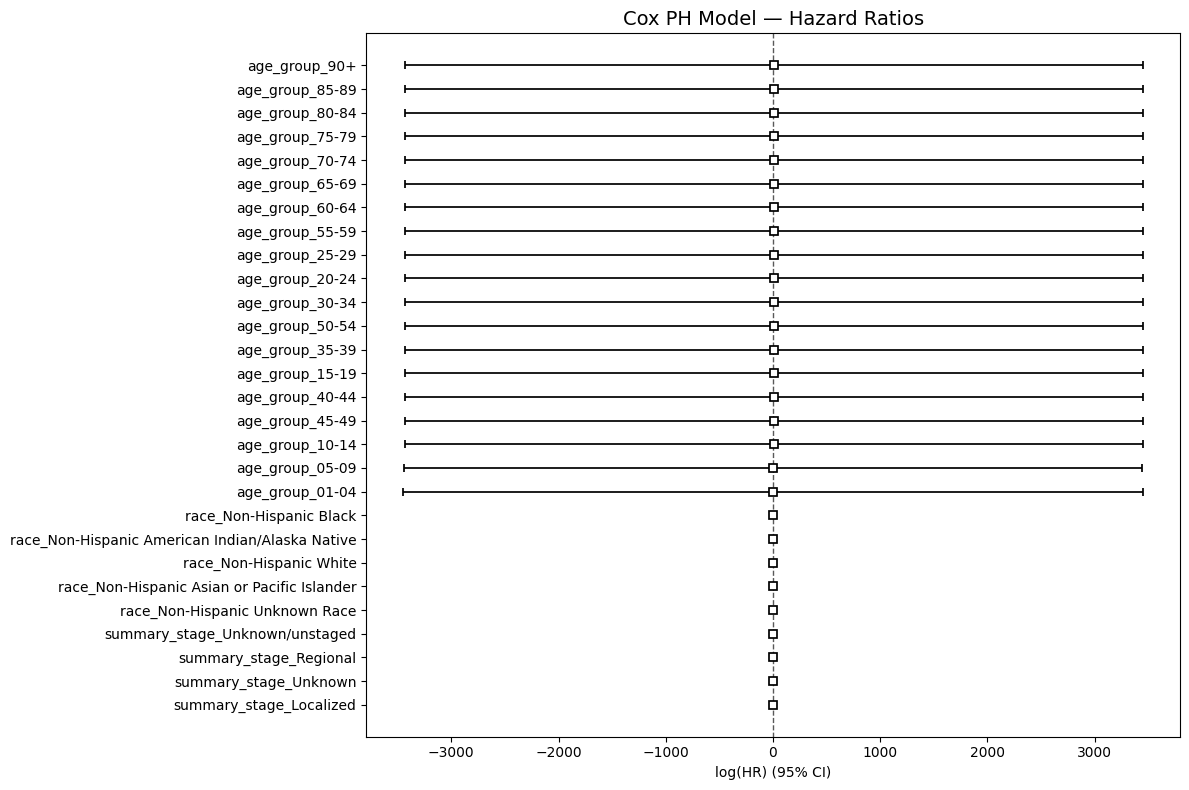

In [67]:
cph_df = df[['survival_months', 'vital_status_binary',
             'summary_stage', 'race', 'age_group']].copy()

# Encode categoricals
cph_df = pd.get_dummies(cph_df, columns=['summary_stage', 'race', 'age_group'],
                         drop_first=True)

cph = CoxPHFitter()
cph.fit(cph_df, duration_col='survival_months',
        event_col='vital_status_binary')

cph.print_summary()

plt.figure(figsize=(12,8))
cph.plot()
plt.title('Cox PH Model — Hazard Ratios', fontsize=14)
plt.tight_layout()
plt.savefig('cox_ph_model.png', dpi=150)
plt.show()

run the Cox PH model

/usr/local/lib/python3.12/dist-packages/lifelines/utils/__init__.py:1100: ConvergenceWarning: Column(s) ['age_group_01-04', 'age_group_05-09', 'age_group_10-14', 'age_group_15-19'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.

  warnings.warn(dedent(warning_text), ConvergenceWarning)


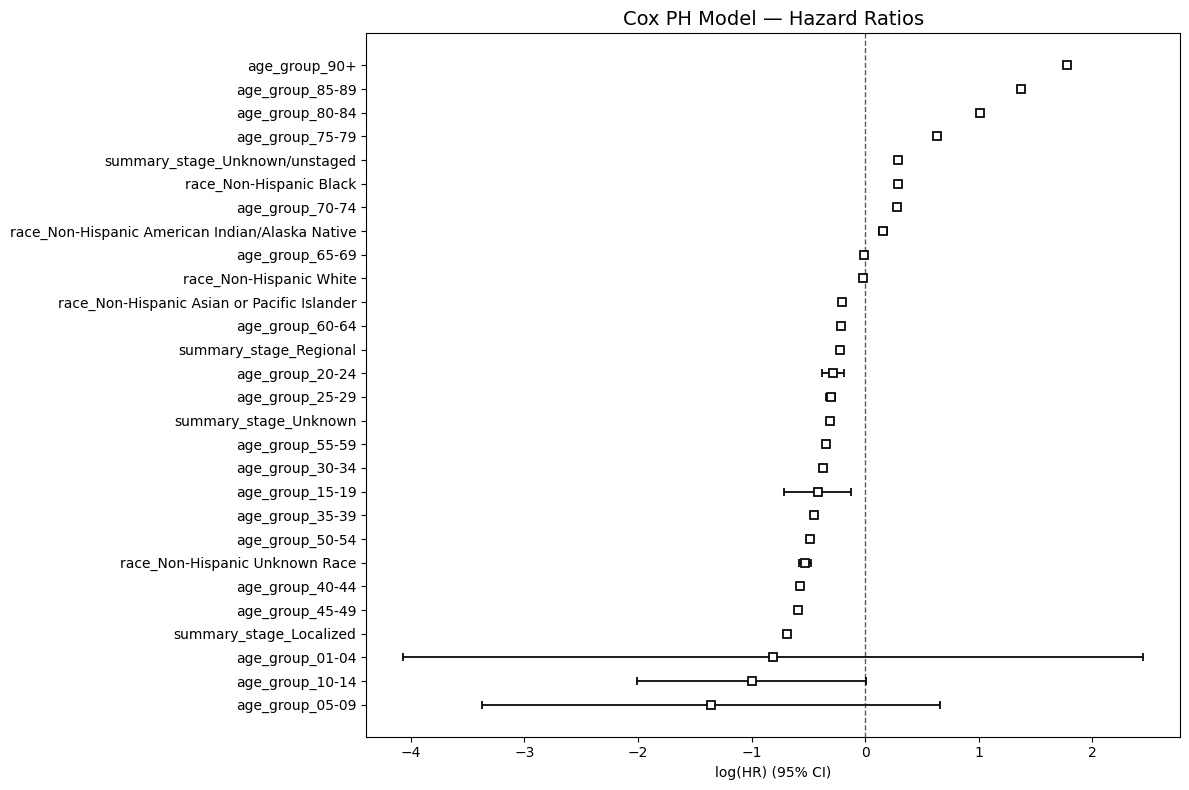

In [68]:
cph_df = df[['survival_months', 'vital_status_binary',
             'summary_stage', 'race', 'age_group']].copy()

# Scale survival months
cph_df['survival_months'] = cph_df['survival_months'] / 12

cph_df = pd.get_dummies(cph_df, columns=['summary_stage', 'race', 'age_group'],
                         drop_first=True)

cph = CoxPHFitter(penalizer=0.1)
cph.fit(cph_df, duration_col='survival_months',
        event_col='vital_status_binary')

plt.figure(figsize=(12,8))
cph.plot()
plt.title('Cox PH Model — Hazard Ratios', fontsize=14)
plt.tight_layout()
plt.savefig('cox_ph_model.png', dpi=150)
plt.show()

In [69]:
print("Survival Analysis Complete!")
print("Charts saved:")
print("- km_curve_stage.png")
print("- km_curve_race.png")
print("- cox_ph_model.png")

Survival Analysis Complete!
Charts saved:
- km_curve_stage.png
- km_curve_race.png
- cox_ph_model.png


# ML Model

 ML Setup

In [70]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE

print("Libraries loaded!")

Libraries loaded!


Feature preparation

In [71]:
# Select features
features = ['age_group', 'sex', 'year_diagnosis', 'summary_stage',
            'radiation', 'race', 'grade_clean']

target = 'vital_status_binary'

ml_df = df[features + [target]].copy()

# Encode categoricals
le = LabelEncoder()
for col in ['age_group', 'sex', 'summary_stage',
            'radiation', 'race', 'grade_clean']:
    ml_df[col] = le.fit_transform(ml_df[col].astype(str))

print(ml_df.shape)
print(ml_df.isnull().sum())
print(ml_df.head())

(1354259, 8)
age_group              0
sex                    0
year_diagnosis         0
summary_stage          0
radiation              0
race                   0
grade_clean            0
vital_status_binary    0
dtype: int64
   age_group  sex  year_diagnosis  summary_stage  radiation  race  \
0         16    0            2003              2          2     5   
1         15    0            2010              1          0     3   
2         15    0            2018              3          0     5   
3         13    0            2005              2          2     5   
4         15    0            2005              2          2     5   

   grade_clean  vital_status_binary  
0            5                    1  
1            5                    1  
2            5                    0  
3            5                    1  
4            5                    1  


In [73]:
print(df['vital_status_binary'].value_counts())
print(f"\nMortality rate: {df['vital_status_binary'].mean()*100:.1f}%")

vital_status_binary
0    917617
1    436642
Name: count, dtype: int64

Mortality rate: 32.2%


Train/test split + SMOTE

In [74]:
X = ml_df.drop(columns=['vital_status_binary'])
y = ml_df['vital_status_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")
print(f"Train class distribution:\n{y_train.value_counts()}")

Train size: (1083407, 7)
Test size: (270852, 7)
Train class distribution:
vital_status_binary
0    734093
1    349314
Name: count, dtype: int64


Train XGBoost model

In [75]:
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=734093/349314,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)
print("Model trained!")

Model trained!


 Model evaluation

In [76]:
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.3f}")

              precision    recall  f1-score   support

           0       0.87      0.81      0.84    183524
           1       0.65      0.75      0.69     87328

    accuracy                           0.79    270852
   macro avg       0.76      0.78      0.76    270852
weighted avg       0.80      0.79      0.79    270852

ROC-AUC Score: 0.863


 Confusion matrix + ROC curve

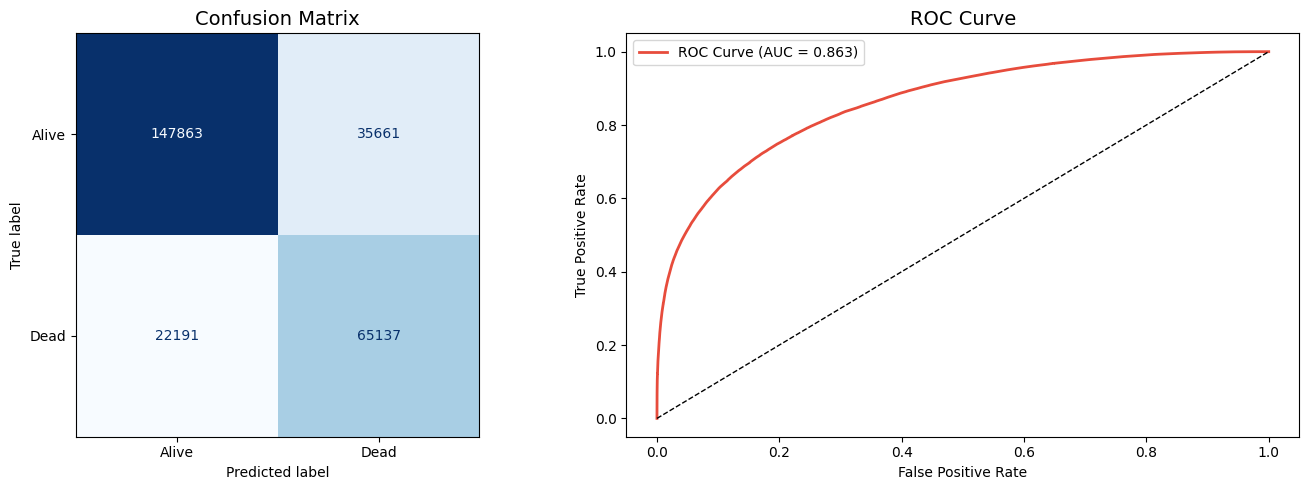

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Alive', 'Dead'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=14)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2,
             label=f'ROC Curve (AUC = 0.863)')
axes[1].plot([0,1], [0,1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150)
plt.show()

Feature importance

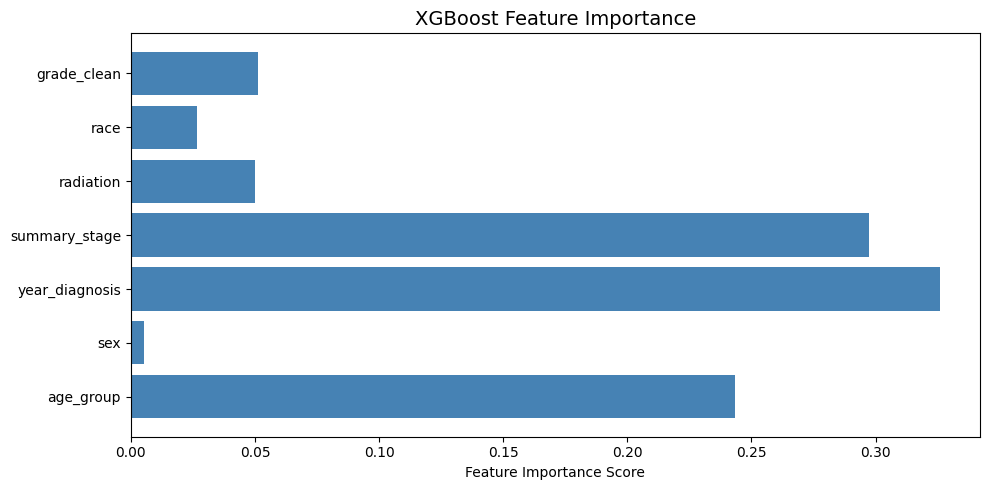

year_diagnosis: 0.3258
summary_stage: 0.2975
age_group: 0.2435
grade_clean: 0.0512
radiation: 0.0500
race: 0.0267
sex: 0.0053


In [78]:
feature_names = X.columns.tolist()
importance = xgb_model.feature_importances_

plt.figure(figsize=(10,5))
bars = plt.barh(feature_names, importance, color='steelblue')
plt.xlabel('Feature Importance Score')
plt.title('XGBoost Feature Importance', fontsize=14)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

for name, imp in sorted(zip(feature_names, importance),
                          key=lambda x: x[1], reverse=True):
    print(f"{name}: {imp:.4f}")

#summary tables for Tableau

In [79]:
# Table 1 - Mortality by stage
stage_summary = df.groupby('summary_stage').agg(
    total_patients=('vital_status_binary', 'count'),
    total_deaths=('vital_status_binary', 'sum'),
    avg_survival=('survival_months', 'mean')
).reset_index()
stage_summary['mortality_rate'] = (stage_summary['total_deaths'] /
                                    stage_summary['total_patients'] * 100).round(1)

# Table 2 - Mortality by race
race_summary = df.groupby('race').agg(
    total_patients=('vital_status_binary', 'count'),
    total_deaths=('vital_status_binary', 'sum'),
    avg_survival=('survival_months', 'mean')
).reset_index()
race_summary['mortality_rate'] = (race_summary['total_deaths'] /
                                   race_summary['total_patients'] * 100).round(1)

# Table 3 - Yearly trend
yearly_summary = df.groupby('year_diagnosis').agg(
    total_cases=('vital_status_binary', 'count'),
    total_deaths=('vital_status_binary', 'sum')
).reset_index()
yearly_summary['mortality_rate'] = (yearly_summary['total_deaths'] /
                                     yearly_summary['total_cases'] * 100).round(1)

# Save all
stage_summary.to_csv('tableau_stage.csv', index=False)
race_summary.to_csv('tableau_race.csv', index=False)
yearly_summary.to_csv('tableau_yearly.csv', index=False)
df.to_csv('tableau_main.csv', index=False)

print("All Tableau files exported!")
print(f"Stage table: {stage_summary.shape}")
print(f"Race table: {race_summary.shape}")
print(f"Yearly table: {yearly_summary.shape}")

All Tableau files exported!
Stage table: (5, 5)
Race table: (6, 5)
Yearly table: (23, 4)


download all 4 files

In [80]:
from google.colab import files
files.download('tableau_stage.csv')
files.download('tableau_race.csv')
files.download('tableau_yearly.csv')
files.download('tableau_main.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>